# Tahap 4 — Occupancy Ablation Study

**Research Question:** *Does occupancy information provide incremental predictive value for 30-minute-ahead smart-room power forecasting?*

Target eksperimen adalah `power(t+30m)` dalam Watt. Control model tidak menggunakan occupancy, sedangkan treatment model menggunakan feature occupancy dengan model family dan protokol evaluasi yang sama. Eksperimen ini menguji **predictive value**, bukan causality.

In [18]:
# Environment Check
from pathlib import Path
import importlib.metadata
import os
import platform
import sys

EXPECTED_DATASET_SHA256 = 'ca7831a188a191edbf82a673fac90dbb875b5095986ed07699c02530f2a02a0e'
REPOSITORY_URL = 'https://github.com/rehanalfarizu/new_jurnal.git'
IS_COLAB = 'google.colab' in sys.modules

def find_repository_root():
    candidates = [Path.cwd(), Path.cwd() / 'new_jurnal', Path.cwd().parent]
    for candidate in candidates:
        if (candidate / 'configs' / 'experiment.yaml').is_file() and (candidate / 'src').is_dir():
            return candidate.resolve()
    return None

REPO_ROOT = find_repository_root()
packages = ['numpy', 'pandas', 'scikit-learn', 'matplotlib', 'PyYAML']
print('Python:', sys.version.split()[0])
print('Platform:', platform.platform())
print('Google Colab:', IS_COLAB)
print('Repository path:', REPO_ROOT or 'belum ditemukan')
for package in packages:
    try:
        version = importlib.metadata.version(package)
    except importlib.metadata.PackageNotFoundError:
        version = 'belum terpasang'
    print(f'{package}: {version}')

Python: 3.11.9
Platform: macOS-15.7-x86_64-i386-64bit
Google Colab: False
Repository path: /Users/macbookpro/Documents/new_jurnal
numpy: 2.3.5
pandas: 2.3.3
scikit-learn: 1.8.0
matplotlib: 3.10.8
PyYAML: 6.0.3


In [19]:
# Google Colab Setup
import subprocess

if IS_COLAB and REPO_ROOT is None:
    clone_target = Path('/content/new_jurnal')
    if not clone_target.exists():
        subprocess.run(['git', 'clone', REPOSITORY_URL, str(clone_target)], check=True)
    REPO_ROOT = clone_target.resolve()
elif REPO_ROOT is None:
    raise RuntimeError('Repository tidak ditemukan. Jalankan notebook dari root new_jurnal atau direktori notebooks/.')

os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print('Working directory:', Path.cwd())

Working directory: /Users/macbookpro/Documents/new_jurnal


In [20]:
# Dependency Installation
import importlib.util

if IS_COLAB:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', 'requirements.txt'], check=True)
    print('Dependency dari requirements.txt telah dipasang.')
else:
    required_modules = {
        'numpy': 'numpy',
        'pandas': 'pandas',
        'scikit-learn': 'sklearn',
        'matplotlib': 'matplotlib',
        'PyYAML': 'yaml',
    }
    missing_dependencies = [
        package for package, module in required_modules.items()
        if importlib.util.find_spec(module) is None
    ]
    if missing_dependencies:
        raise ModuleNotFoundError(
            'Kernel Jupyter aktif belum memiliki dependency: '
            + ', '.join(missing_dependencies)
            + f'. Pasang dengan: {sys.executable} -m pip install -r requirements.txt '
            + 'atau pilih kernel environment proyek yang sudah siap.'
        )
    print('Dependency lokal terverifikasi pada kernel Jupyter aktif.')

Dependency lokal terverifikasi pada kernel Jupyter aktif.


In [21]:
# Dataset Location
# Prioritas: SENSOR_DATA_PATH -> data/raw -> satu kandidat pada folder proyek saudara.
# Opsi Google Drive (aktifkan dan sesuaikan path hanya bila dijalankan di Colab):
# from google.colab import drive
# drive.mount('/content/drive')
# os.environ['SENSOR_DATA_PATH'] = '/content/drive/MyDrive/.../sensor_data.csv'

configured_path = os.environ.get('SENSOR_DATA_PATH', '').strip()
default_dataset_path = (REPO_ROOT / 'data/raw/sensor_data.csv').resolve()
dataset_path_source = 'data/raw/sensor_data.csv'

if configured_path:
    DATASET_PATH = Path(configured_path).expanduser()
    if not DATASET_PATH.is_absolute():
        DATASET_PATH = (REPO_ROOT / DATASET_PATH).resolve()
    dataset_path_source = 'environment variable SENSOR_DATA_PATH'
elif default_dataset_path.is_file():
    DATASET_PATH = default_dataset_path
elif not IS_COLAB:
    sibling_candidates_by_file = {}
    for pattern in ('*/Data/sensor_data.csv', '*/data/sensor_data.csv'):
        for path in REPO_ROOT.parent.glob(pattern):
            if path.is_file():
                file_stat = path.stat()
                sibling_candidates_by_file[(file_stat.st_dev, file_stat.st_ino)] = path.resolve()
    sibling_candidates = sorted(sibling_candidates_by_file.values())
    if len(sibling_candidates) == 1:
        DATASET_PATH = sibling_candidates[0]
        dataset_path_source = 'satu kandidat dataset pada folder proyek saudara'
    elif len(sibling_candidates) > 1:
        candidate_list = '\n'.join(f'- {path}' for path in sibling_candidates)
        raise RuntimeError(
            'Ditemukan lebih dari satu kandidat sensor_data.csv. '
            'Tetapkan SENSOR_DATA_PATH secara eksplisit:\n' + candidate_list
        )
    else:
        DATASET_PATH = default_dataset_path
else:
    DATASET_PATH = default_dataset_path

ALLOW_DIFFERENT_DATASET = False
print('Dataset path:', DATASET_PATH)
print('Sumber resolusi path:', dataset_path_source)
if not DATASET_PATH.is_file():
    print('Dataset belum ditemukan; sel pemeriksaan integritas berikutnya akan menampilkan petunjuk konfigurasi.')

Dataset path: /Users/macbookpro/Documents/jurnal_penelitian/data/sensor_data.csv
Sumber resolusi path: satu kandidat dataset pada folder proyek saudara


In [22]:
# Dataset Integrity
import hashlib
import warnings

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()

if not DATASET_PATH.is_file():
    raise FileNotFoundError(
        f'sensor_data.csv tidak ditemukan di {DATASET_PATH}.\n'
        'Jupyter lokal: tetapkan environment variable SENSOR_DATA_PATH ke path file.\n'
        'Google Colab: mount Google Drive, lalu tetapkan SENSOR_DATA_PATH.\n'
        'Alternatif: letakkan file pada data/raw/sensor_data.csv.'
    )
DATASET_SHA256 = sha256_file(DATASET_PATH)
CHECKSUM_MATCH = DATASET_SHA256 == EXPECTED_DATASET_SHA256
print('SHA-256:', DATASET_SHA256)
print('Checksum sesuai dataset penelitian:', CHECKSUM_MATCH)
if not CHECKSUM_MATCH:
    warnings.warn('WARNING: checksum dataset berbeda dari dataset penelitian.', RuntimeWarning)
    if not ALLOW_DIFFERENT_DATASET:
        raise ValueError('Eksperimen dihentikan. Set ALLOW_DIFFERENT_DATASET=True hanya setelah review eksplisit.')

SHA-256: ca7831a188a191edbf82a673fac90dbb875b5095986ed07699c02530f2a02a0e
Checksum sesuai dataset penelitian: True


In [23]:
# Load Experiment Configuration
import pandas as pd
import yaml
from IPython.display import display

with Path('configs/experiment.yaml').open(encoding='utf-8') as handle:
    experiment_config = yaml.safe_load(handle)
with Path('configs/features.yaml').open(encoding='utf-8') as handle:
    feature_config = yaml.safe_load(handle)

config_summary = pd.DataFrame([
    {'setting': 'cadence_minutes', 'value': experiment_config['forecast']['cadence_minutes']},
    {'setting': 'forecast_horizon_minutes', 'value': experiment_config['forecast']['horizon_minutes']},
    {'setting': 'split', 'value': f"{experiment_config['evaluation']['train_fraction']:.0%}/{experiment_config['evaluation']['validation_fraction']:.0%}/{experiment_config['evaluation']['test_fraction']:.0%}"},
    {'setting': 'model_family', 'value': 'Ridge'},
    {'setting': 'ridge_alphas', 'value': experiment_config['forecast']['ridge_alphas']},
    {'setting': 'random_seed', 'value': experiment_config['random_seed']},
    {'setting': 'control_feature_count', 'value': len(feature_config['model_feature_sets']['non_occupancy_multivariate_ridge'])},
    {'setting': 'treatment_feature_count', 'value': len(feature_config['model_feature_sets']['occupancy_multivariate_ridge'])},
])
display(config_summary)

,setting,value
0,cadence_minutes,1
1,forecast_horizon_minutes,30
2,split,70%/15%/15%
3,model_family,Ridge
4,ridge_alphas,"[0.1, 1.0, 10.0, 100.0]"
5,random_seed,42
6,control_feature_count,20
7,treatment_feature_count,31


In [24]:
# Build / Load Modeling Dataset
import json
from src.forecasting.occupancy_ablation import run_occupancy_ablation

MANIFEST_PATH = Path('results/metrics/occupancy_ablation_manifest.json')
FORCE_RERUN = os.environ.get('FORCE_OCCUPANCY_ABLATION', '0') == '1'
manifest_is_current = False
if MANIFEST_PATH.is_file():
    existing_manifest = json.loads(MANIFEST_PATH.read_text(encoding='utf-8'))
    code_is_current = all(
        Path(path).is_file() and sha256_file(path) == checksum
        for path, checksum in existing_manifest.get('code_sha256', {}).items()
    )
    manifest_is_current = (
        existing_manifest.get('input_sha256') == DATASET_SHA256
        and existing_manifest.get('config_sha256') == sha256_file('configs/experiment.yaml')
        and existing_manifest.get('features_config_sha256') == sha256_file('configs/features.yaml')
        and code_is_current
    )
if FORCE_RERUN or not manifest_is_current:
    pipeline_result = run_occupancy_ablation(input_path=DATASET_PATH)
    print('Pipeline Tahap 4 dijalankan ulang.')
else:
    print('Output resmi yang cocok dengan dataset dan konfigurasi ditemukan; hasil dimuat ulang.')

manifest = json.loads(MANIFEST_PATH.read_text(encoding='utf-8'))
modeling_summary = pd.DataFrame([
    {'metric': 'raw_records', 'value': manifest['raw_records']},
    {'metric': 'minute_bins', 'value': manifest['minute_bins']},
    {'metric': 'usable_samples', 'value': manifest['common_usable_samples']},
    {'metric': 'excluded_samples', 'value': manifest['excluded_samples']},
])
display(modeling_summary)

Output resmi yang cocok dengan dataset dan konfigurasi ditemukan; hasil dimuat ulang.


,metric,value
0,raw_records,2027520
1,minute_bins,128289
2,usable_samples,121698
3,excluded_samples,6591


In [25]:
# Temporal Split Verification
split_table = pd.read_csv('results/tables/temporal_split.csv')
manifest_split = pd.DataFrame(manifest['split'])
columns = ['split', 'start_timestamp_utc', 'end_timestamp_utc', 'minute_bins']
split_matches_stage3 = split_table[columns].astype(str).equals(manifest_split[columns].astype(str))
print('Split sama dengan boundary Tahap 3:', split_matches_stage3)
if not split_matches_stage3:
    raise AssertionError('Boundary Tahap 4 berbeda dari temporal split Tahap 3.')
display(split_table[['split', 'start_timestamp_utc', 'end_timestamp_utc', 'minute_bins', 'usable_samples']])

Split sama dengan boundary Tahap 3: True


,split,start_timestamp_utc,end_timestamp_utc,minute_bins,usable_samples
0,train,2026-02-23T23:14:00Z,2026-04-27T07:55:00Z,89802,85242
1,validation,2026-04-27T07:56:00Z,2026-05-10T16:38:00Z,19243,18330
2,test,2026-05-10T16:39:00Z,2026-05-24T01:22:00Z,19244,18126


In [26]:
# Control Model
comparison = pd.read_csv('results/tables/occupancy_ablation_comparison.csv')
control = comparison.loc[comparison['role'] == 'control'].iloc[0]
control_features = feature_config['model_feature_sets']['non_occupancy_multivariate_ridge']
print('Feature set:', control_features)
display(pd.DataFrame([{
    'model': control['model'],
    'selected_alpha': control['selected_alpha'],
    'validation_mae_w': control['validation_mae_w'],
    'test_mae_w': control['test_mae_w'],
    'test_rmse_w': control['test_rmse_w'],
    'test_r2': control['test_r2'],
}]))

Feature set: ['power_w', 'power_lag_1m', 'power_lag_5m', 'power_lag_15m', 'power_lag_30m', 'power_rolling_mean_5m', 'power_rolling_std_5m', 'power_rolling_mean_15m', 'power_rolling_std_15m', 'power_rolling_mean_30m', 'power_rolling_std_30m', 'hour_of_day_sin', 'hour_of_day_cos', 'day_of_week_sin', 'day_of_week_cos', 'is_weekend', 'temperature_c', 'humidity_percent', 'voltage_v', 'current_a']


,model,selected_alpha,validation_mae_w,test_mae_w,test_rmse_w,test_r2
0,non_occupancy_multivariate_ridge,0.1,1.074802,1.080099,1.620865,0.64716


In [27]:
# Occupancy Treatment Model
treatment = comparison.loc[comparison['role'] == 'treatment'].iloc[0]
control_set = set(feature_config['model_feature_sets']['non_occupancy_multivariate_ridge'])
treatment_features = feature_config['model_feature_sets']['occupancy_multivariate_ridge']
occupancy_features = [feature for feature in treatment_features if feature not in control_set]
print('Occupancy features:', occupancy_features)
display(pd.DataFrame([{
    'model': treatment['model'],
    'selected_alpha': treatment['selected_alpha'],
    'validation_mae_w': treatment['validation_mae_w'],
    'test_mae_w': treatment['test_mae_w'],
    'test_rmse_w': treatment['test_rmse_w'],
    'test_r2': treatment['test_r2'],
}]))

Occupancy features: ['occupancy_count', 'occupancy_lag_1m', 'occupancy_lag_5m', 'occupancy_lag_15m', 'occupancy_lag_30m', 'occupancy_rolling_mean_5m', 'occupancy_rolling_max_5m', 'occupancy_rolling_mean_15m', 'occupancy_rolling_max_15m', 'occupancy_rolling_mean_30m', 'occupancy_rolling_max_30m']


,model,selected_alpha,validation_mae_w,test_mae_w,test_rmse_w,test_r2
0,occupancy_multivariate_ridge,10.0,1.065041,1.069389,1.600945,0.65578


In [28]:
# Fair Ablation Check
fair_checks = pd.read_csv('results/tables/fair_ablation_check.csv')
fair_checks['status'] = fair_checks['passed'].map({True: 'PASS', False: 'FAIL'})
display(fair_checks[['check', 'status', 'detail']])
if not fair_checks['passed'].all():
    raise AssertionError('Fair ablation check gagal. Hasil tidak boleh diinterpretasikan.')

,check,status,detail
0,control_sample_timestamp_equals_treatment,PASS,121698 control dan 121698 treatment samples
1,control_target_equals_treatment,PASS,Target dibandingkan setelah alignment timestamp
2,control_split_equals_treatment,PASS,Label split dibandingkan setelah alignment tim...
3,model_family_equal,PASS,Ridge untuk control dan treatment
4,tuning_budget_equal,PASS,"[0.1, 1.0, 10.0, 100.0]"
5,preprocessing_policy_equal,PASS,"Satu resampling, target, gap policy, dan sampl..."


In [29]:
# Ablation Results
ablation_results = comparison[[
    'model', 'test_mae_w', 'test_rmse_w', 'test_r2',
    'delta_mae_w_vs_control', 'delta_rmse_w_vs_control',
    'mae_improvement_w_vs_control', 'mae_percentage_improvement'
]].rename(columns={
    'model': 'Model',
    'test_mae_w': 'MAE (W)',
    'test_rmse_w': 'RMSE (W)',
    'test_r2': 'R²',
    'delta_mae_w_vs_control': 'Delta MAE: treatment - control (W)',
    'delta_rmse_w_vs_control': 'Delta RMSE: treatment - control (W)',
    'mae_improvement_w_vs_control': 'MAE improvement: control - treatment (W)',
    'mae_percentage_improvement': 'Percentage Improvement MAE (%)',
})
display(ablation_results)

,Model,MAE (W),RMSE (W),R²,Delta MAE: treatment - control (W),Delta RMSE: treatment - control (W),MAE improvement: control - treatment (W),Percentage Improvement MAE (%)
0,non_occupancy_multivariate_ridge,1.080099,1.620865,0.64716,0.00000,0.00000,0.00000,0.000000
1,occupancy_multivariate_ridge,1.069389,1.600945,0.65578,-0.01071,-0.01992,0.01071,0.991595


In [30]:
# Occupancy-Level Error
occupancy_level_error = pd.read_csv('results/tables/occupancy_level_error.csv')
display(occupancy_level_error.rename(columns={
    'occupancy_count': 'occupancy',
    'sample_count': 'N',
    'control_mae_w': 'MAE control (W)',
    'treatment_mae_w': 'MAE occupancy (W)',
    'difference_treatment_minus_control_w': 'difference (W)',
}))

,occupancy,N,MAE control (W),MAE occupancy (W),difference (W)
0,0,899,1.068204,1.021928,-0.046276
1,1,1437,1.023402,1.047253,0.023851
2,2,3363,1.333150,1.328329,-0.004822
3,3,5115,1.042077,1.038095,-0.003982
4,4,4071,1.023582,1.005231,-0.018351
5,5,3241,0.976958,0.953659,-0.023299


In [31]:
# Uncertainty Analysis
bootstrap = pd.read_csv('results/metrics/occupancy_ablation_bootstrap.csv')
display(bootstrap[[
    'method', 'metric', 'metric_definition', 'block_size_samples',
    'iterations', 'confidence_level', 'observed_mae_improvement_w',
    'mae_improvement_ci_lower_w', 'mae_improvement_ci_upper_w',
    'supports_positive_improvement'
]])
print('Bootstrap menggunakan contiguous blocks, bukan independent-row resampling.')

,method,metric,metric_definition,block_size_samples,iterations,confidence_level,observed_mae_improvement_w,mae_improvement_ci_lower_w,mae_improvement_ci_upper_w,supports_positive_improvement
0,moving_block_bootstrap_paired_absolute_error_i...,mae_improvement_w,mae_control_minus_mae_treatment,1440,1000,0.95,0.01071,-0.00618,0.021583,False


Bootstrap menggunakan contiguous blocks, bukan independent-row resampling.


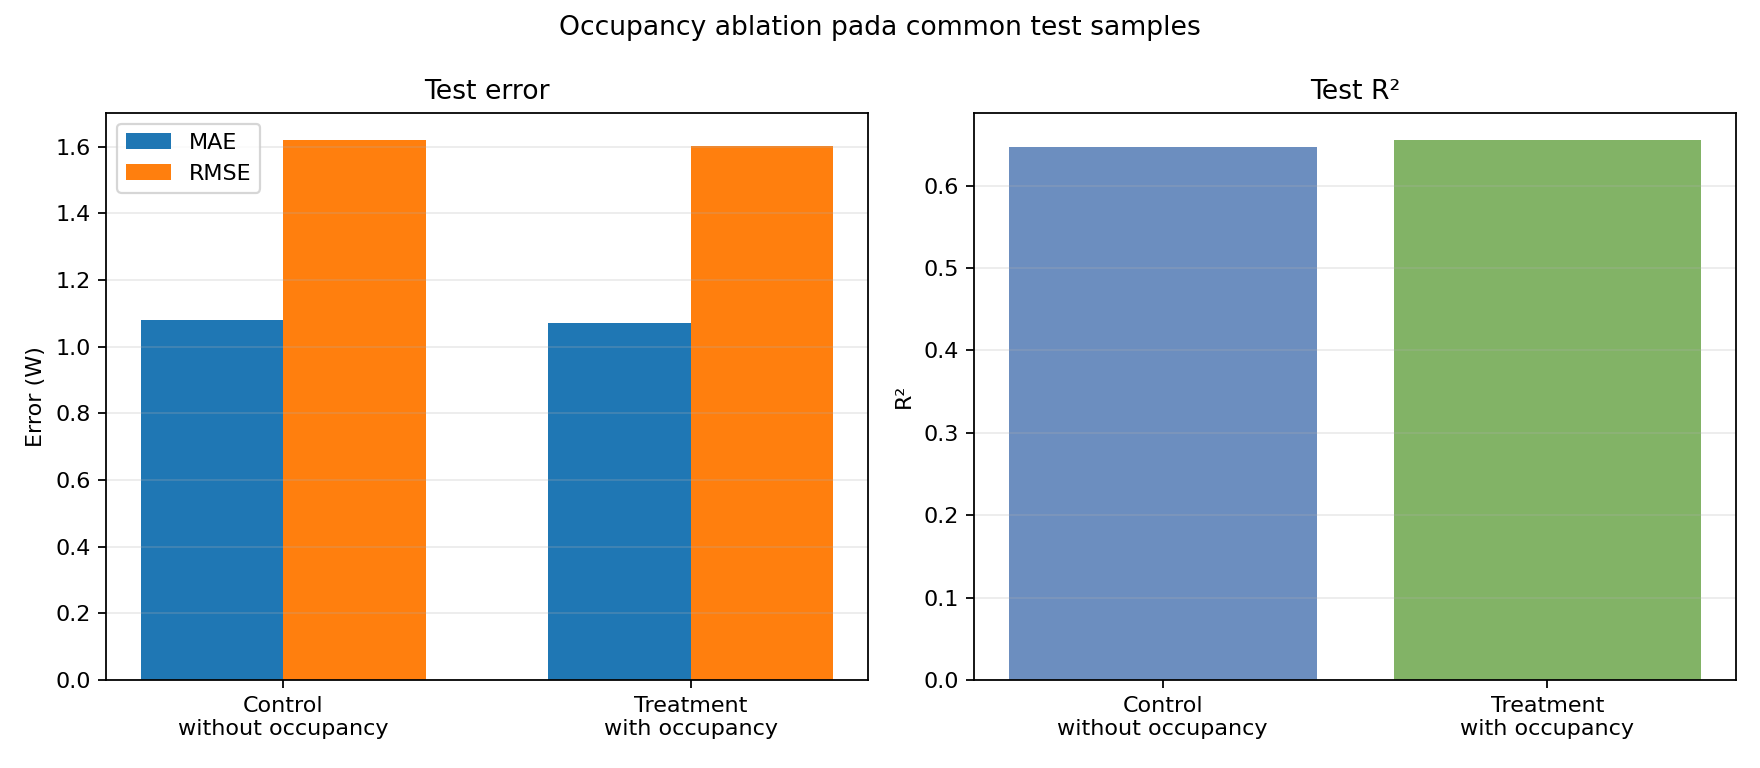

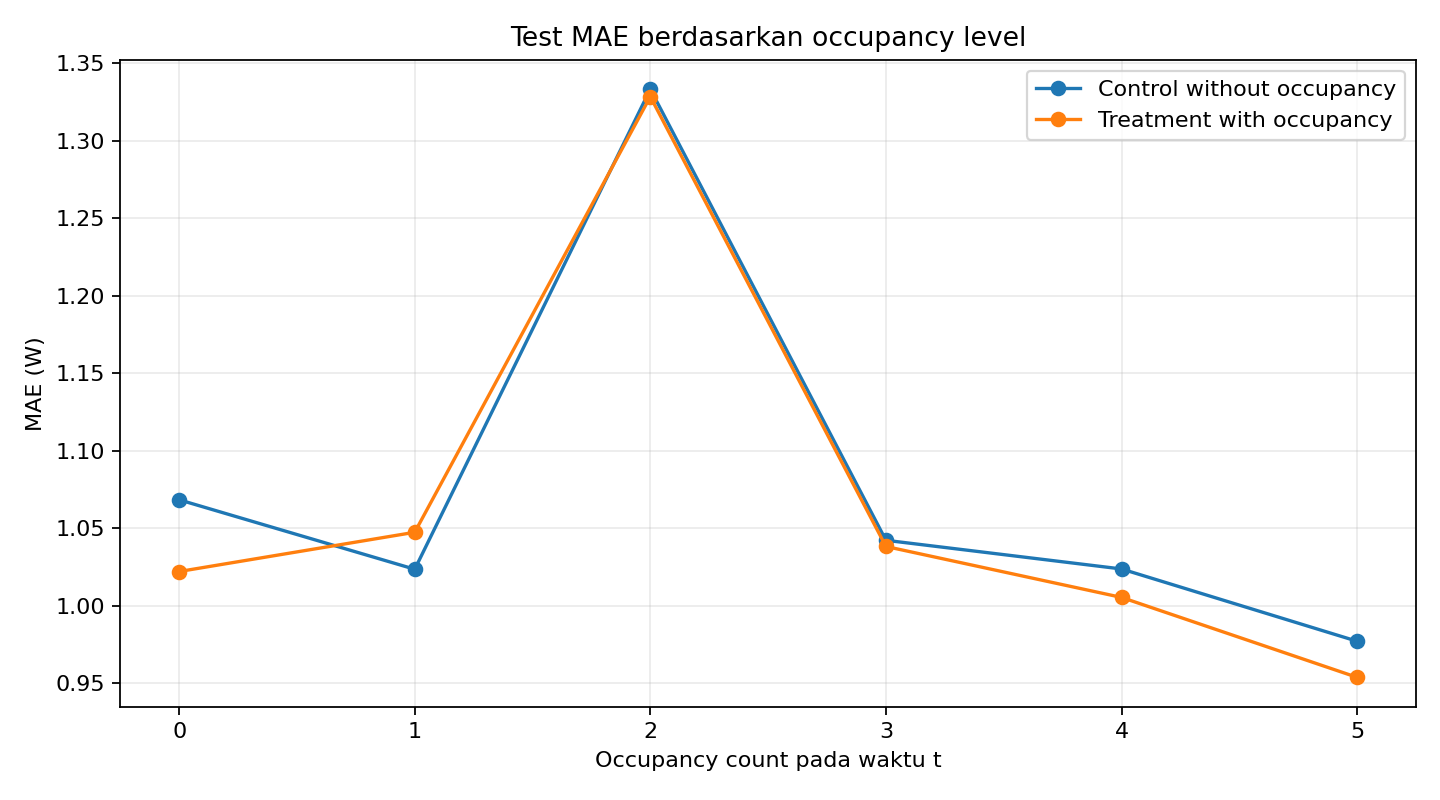

In [32]:
# Visualization
from IPython.display import Image, display

for figure_path in [
    Path('results/figures/occupancy_ablation_comparison.png'),
    Path('results/figures/occupancy_level_error.png'),
]:
    if not figure_path.is_file():
        raise FileNotFoundError(f'Figure pipeline tidak ditemukan: {figure_path}')
    display(Image(filename=str(figure_path)))

In [33]:
# Research Interpretation berdasarkan hasil aktual
from IPython.display import Markdown

mae_delta = float(treatment['delta_mae_w_vs_control'])
mae_improvement = float(treatment['mae_improvement_w_vs_control'])
improvement_percent = float(treatment['mae_percentage_improvement'])
bootstrap_row = bootstrap.iloc[0]
improved_levels = occupancy_level_error.loc[
    occupancy_level_error['difference_treatment_minus_control_w'] < 0, 'occupancy_count'
].astype(int).tolist()
worse_levels = occupancy_level_error.loc[
    occupancy_level_error['difference_treatment_minus_control_w'] > 0, 'occupancy_count'
].astype(int).tolist()
direction = 'menurunkan' if mae_delta < 0 else 'meningkatkan'
ci_statement = (
    'seluruhnya berada di atas nol' if bootstrap_row['supports_positive_improvement']
    else 'mencakup nol'
)
display(Markdown(f'''
### Interpretasi

Treatment occupancy {direction} test MAE sebesar **{abs(mae_delta):.6f} W** atau **{improvement_percent:.3f}%** relatif terhadap control. MAE lebih rendah terlihat pada occupancy level **{improved_levels}**, sedangkan MAE lebih tinggi terlihat pada level **{worse_levels}**.

Dengan definisi `delta_mae = MAE_treatment - MAE_control` dan `mae_improvement = MAE_control - MAE_treatment`, observed MAE improvement adalah **{mae_improvement:.6f} W**. Moving-block bootstrap 95% menghasilkan interval **[{bootstrap_row['mae_improvement_ci_lower_w']:.6f}, {bootstrap_row['mae_improvement_ci_upper_w']:.6f}] W** untuk `mae_improvement`. Interval tersebut {ci_statement}, sehingga hasil ini tidak cukup untuk menyatakan penurunan error yang konsisten bila interval masih mencakup nol.

Analisis ini menguji predictive value, bukan causality. Occupancy menggunakan latest available camera snapshot dan tidak memiliki timestamp independen untuk mengukur staleness atau sinkronisasi presisi.
'''))


### Interpretasi

Treatment occupancy menurunkan test MAE sebesar **0.010710 W** atau **0.992%** relatif terhadap control. MAE lebih rendah terlihat pada occupancy level **[0, 2, 3, 4, 5]**, sedangkan MAE lebih tinggi terlihat pada level **[1]**.

Dengan definisi `delta_mae = MAE_treatment - MAE_control` dan `mae_improvement = MAE_control - MAE_treatment`, observed MAE improvement adalah **0.010710 W**. Moving-block bootstrap 95% menghasilkan interval **[-0.006180, 0.021583] W** untuk `mae_improvement`. Interval tersebut mencakup nol, sehingga hasil ini tidak cukup untuk menyatakan penurunan error yang konsisten bila interval masih mencakup nol.

Analisis ini menguji predictive value, bukan causality. Occupancy menggunakan latest available camera snapshot dan tidak memiliki timestamp independen untuk mengukur staleness atau sinkronisasi presisi.


In [34]:
# Reproducibility Summary
runtime_packages = {}
for package in ['numpy', 'pandas', 'scikit-learn', 'matplotlib', 'PyYAML']:
    try:
        runtime_packages[package] = importlib.metadata.version(package)
    except importlib.metadata.PackageNotFoundError:
        runtime_packages[package] = 'tidak tersedia'
reproducibility = {
    'dataset_sha256': DATASET_SHA256,
    'git_commit': manifest.get('git_commit'),
    'working_tree_dirty': manifest.get('working_tree_dirty'),
    'python_version': sys.version.split()[0],
    'package_versions': runtime_packages,
    'random_seed': experiment_config['random_seed'],
    'forecast_horizon_minutes': experiment_config['forecast']['horizon_minutes'],
    'cadence_minutes': experiment_config['forecast']['cadence_minutes'],
    'model_family': 'Ridge',
    'split': 'chronological 70/15/15',
    'generated_output_paths': manifest['official_outputs'],
}
print(json.dumps(reproducibility, ensure_ascii=False, indent=2))

{
  "dataset_sha256": "ca7831a188a191edbf82a673fac90dbb875b5095986ed07699c02530f2a02a0e",
  "git_commit": "cd71c0b8b14b0cc4aef4fda5af5bff5ced964480",
  "working_tree_dirty": true,
  "python_version": "3.11.9",
  "package_versions": {
    "numpy": "2.3.5",
    "pandas": "2.3.3",
    "scikit-learn": "1.8.0",
    "matplotlib": "3.10.8",
    "PyYAML": "6.0.3"
  },
  "random_seed": 42,
  "forecast_horizon_minutes": 30,
  "cadence_minutes": 1,
  "model_family": "Ridge",
  "split": "chronological 70/15/15",
  "generated_output_paths": {
    "comparison": "results/tables/occupancy_ablation_comparison.csv",
    "occupancy_level_error": "results/tables/occupancy_level_error.csv",
    "fair_check": "results/tables/fair_ablation_check.csv",
    "metrics": "results/metrics/occupancy_ablation_metrics.csv",
    "bootstrap": "results/metrics/occupancy_ablation_bootstrap.csv",
    "predictions": "results/metrics/occupancy_ablation_test_predictions.csv",
    "comparison_figure": "results/figures/occupan